# Infiltration Heat Load During Door-Open Variations

This notebook visualizes infiltration heat load over time for each door-open duration case.

In [1]:
# Import required libraries
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Locate the project outputs from either project root or visualization folder
project_root = Path.cwd()
if not (project_root / "outputs").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs"

# Door-open simulation cases
door_cases = {
    "30 s door opening": output_dir / "paper_reference_case_door_30s.csv",
    "60 s door opening": output_dir / "paper_reference_case_door_60s.csv",
    "120 s door opening": output_dir / "paper_reference_case_door_120s.csv",
}

# Different plot styling from the comparison notebook
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

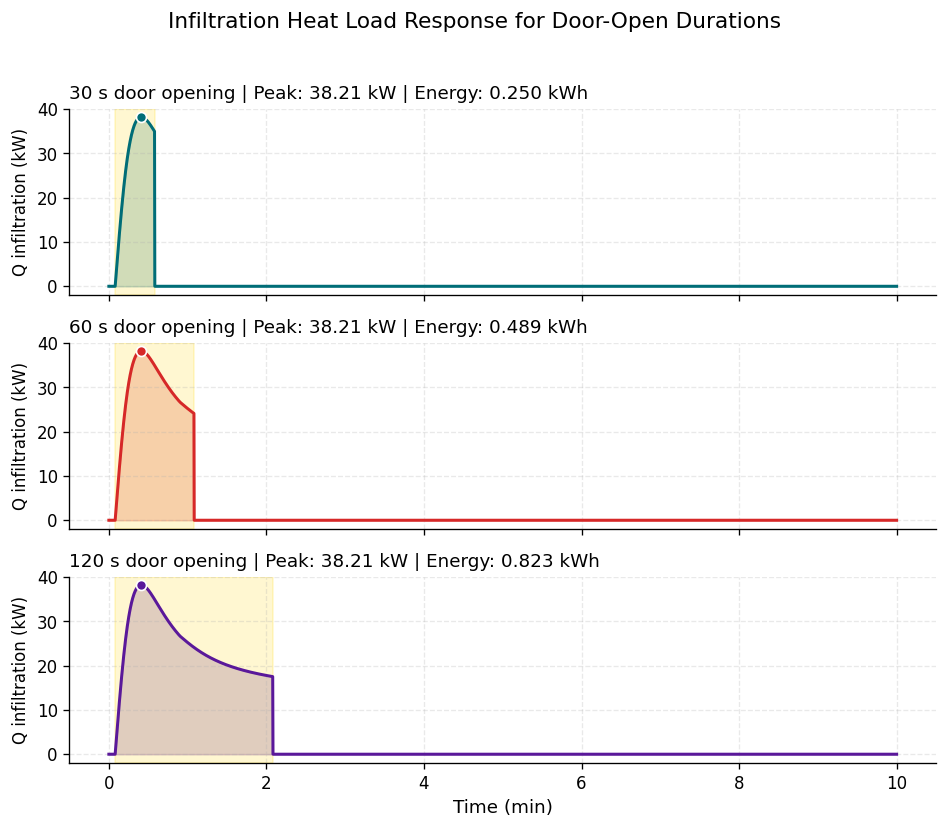

In [2]:
# Plot Q infiltration over time for each door-open variation
fig, axes = plt.subplots(
    nrows=len(door_cases),
    ncols=1,
    figsize=(8, 7),
    sharex=True,
    sharey=True,
)

case_colors = ["#006d77", "#d62828", "#5a189a"]

for ax, (case_name, file_path), color in zip(axes, door_cases.items(), case_colors):
    df = pd.read_csv(file_path)

    # Keep time, total infiltration heat load, and door-open fraction
    df = df[["time_s", "infiltration_total_w", "infiltration_door_open_fraction"]]
    df = df.apply(pd.to_numeric, errors="coerce").dropna()

    time_min = df["time_s"] / 60
    q_infiltration_kw = df["infiltration_total_w"] / 1000
    door_open = df["infiltration_door_open_fraction"] > 0

    # Estimate total infiltration energy using trapezoidal integration in kWh
    dt_h = df["time_s"].diff().fillna(0) / 3600
    q_avg_kw = (q_infiltration_kw + q_infiltration_kw.shift().fillna(q_infiltration_kw.iloc[0])) / 2
    infiltration_energy_kwh = (q_avg_kw * dt_h).sum()

    peak_idx = q_infiltration_kw.idxmax()
    peak_time = time_min.loc[peak_idx]
    peak_q = q_infiltration_kw.loc[peak_idx]

    ax.fill_between(time_min, q_infiltration_kw, color=color, alpha=0.22)
    ax.plot(time_min, q_infiltration_kw, color=color, linewidth=1.8)
    ax.scatter(peak_time, peak_q, color=color, edgecolor="white", zorder=3)

    if door_open.any():
        ax.axvspan(time_min[door_open].min(), time_min[door_open].max(), color="gold", alpha=0.18)

    ax.set_title(
        f"{case_name} | Peak: {peak_q:.2f} kW | Energy: {infiltration_energy_kwh:.3f} kWh",
        loc="left",
        fontsize=11,
    )
    ax.set_ylabel("Q infiltration (kW)", fontsize=10)
    ax.tick_params(direction="out")

axes[-1].set_xlabel("Time (min)", fontsize=11)
fig.suptitle("Infiltration Heat Load Response for Door-Open Durations", fontsize=13, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()